# Grouped Shap Explanations for Credit Card Default Model

Example applying groupShap to explaining a credit default prediction.

In [1]:
import pandas as pd
import xgboost as xgb
import plotly.express as px

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from grouptreeshap import GroupedTreeExplainer

Load *"Default of Credit Card Clients"* from UC Irvine's Machine Learning Repository:

In [2]:
credit = fetch_ucirepo(id=350)
credit.data.features.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


**Data Dictionary:**

> This research employed a binary variable, default payment (Yes = 1, No = 0), as the response variable. This study reviewed the literature and used the following 23 variables as explanatory variables:
> 
> - X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
> 
> - X2: Gender (1 = male; 2 = female).
> 
> - X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
> 
> - X4: Marital status (1 = married; 2 = single; 3 = others).
> 
> - X5: Age (year).
> 
> - X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: X6 = the repayment status in September, 2005; X7 = the repayment status in August, 2005; . . .;X11 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
> 
> - X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 
> 
> - X18-X23: Amount of previous payment (NT dollar). X18 = amount paid in September, 2005; X19 = amount paid in August, 2005; . . .;X23 = amount paid in April, 2005.

Prepare features and get train/test split:

In [3]:
X = credit.data.features.drop(columns=["X2", "X4", "X5"])
X["X3"] = X["X3"].astype("category")
y = credit.data.targets.squeeze()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

Fit simple XGBoost classifier as a default prediction model:

In [4]:
model = xgb.XGBClassifier(enable_categorical=True, random_state=0)
model.fit(X_train, y_train)

print("Model: ", model.__class__.__name__)
print("Accuracy score: ", accuracy_score(y_test, model.predict(X_test)))

Model:  XGBClassifier
Accuracy score:  0.817


Define feature groups:

In [5]:
groups = {
    "Loan amount": ["X1"],
    "Education level": ["X3"],
    "Repayment history": [f"X{i}" for i in range(6, 12)],
    "Outstanding bill amounts": [f"X{i}" for i in range(12, 18)],
    "Repayment amounts": [f"X{i}" for i in range(18, 24)],
}

Transform to index-based membership vector representation:

In [6]:
reprs = {c: cols[0] for cols in groups.values() for c in cols}
feature_reprs = X.columns.get_indexer(X.columns.to_series().replace(reprs))

Get grouped TreeShap values as explanations:

In [7]:
j = 6706
x_applicant = X_test.iloc[j, :]

explainer = GroupedTreeExplainer(model)

shap = explainer.shap_values(
    x_applicant,
    feature_reprs,
)

named_groupshap = {}
for name, cols in groups.items():
    named_groupshap[name] = float(shap[X.columns.get_indexer(cols)][0])

named_groupshap

{'Loan amount': -0.23529301583766937,
 'Education level': -0.0010303943417966366,
 'Repayment history': -0.030237045139074326,
 'Outstanding bill amounts': 0.14806246757507324,
 'Repayment amounts': 0.05846041068434715}

Compare to sum-of-shap values:

In [8]:
singleton_shap = explainer.shap_values(x_applicant)

named_sum_of_shap = {}
for name, cols in groups.items():
    named_sum_of_shap[name] = float(sum(singleton_shap[X.columns.get_indexer(cols)]))

named_sum_of_shap

{'Loan amount': -0.2084590196609497,
 'Education level': 0.029448866844177246,
 'Repayment history': -0.2140839397907257,
 'Outstanding bill amounts': 0.022401683032512665,
 'Repayment amounts': 0.3106543719768524}

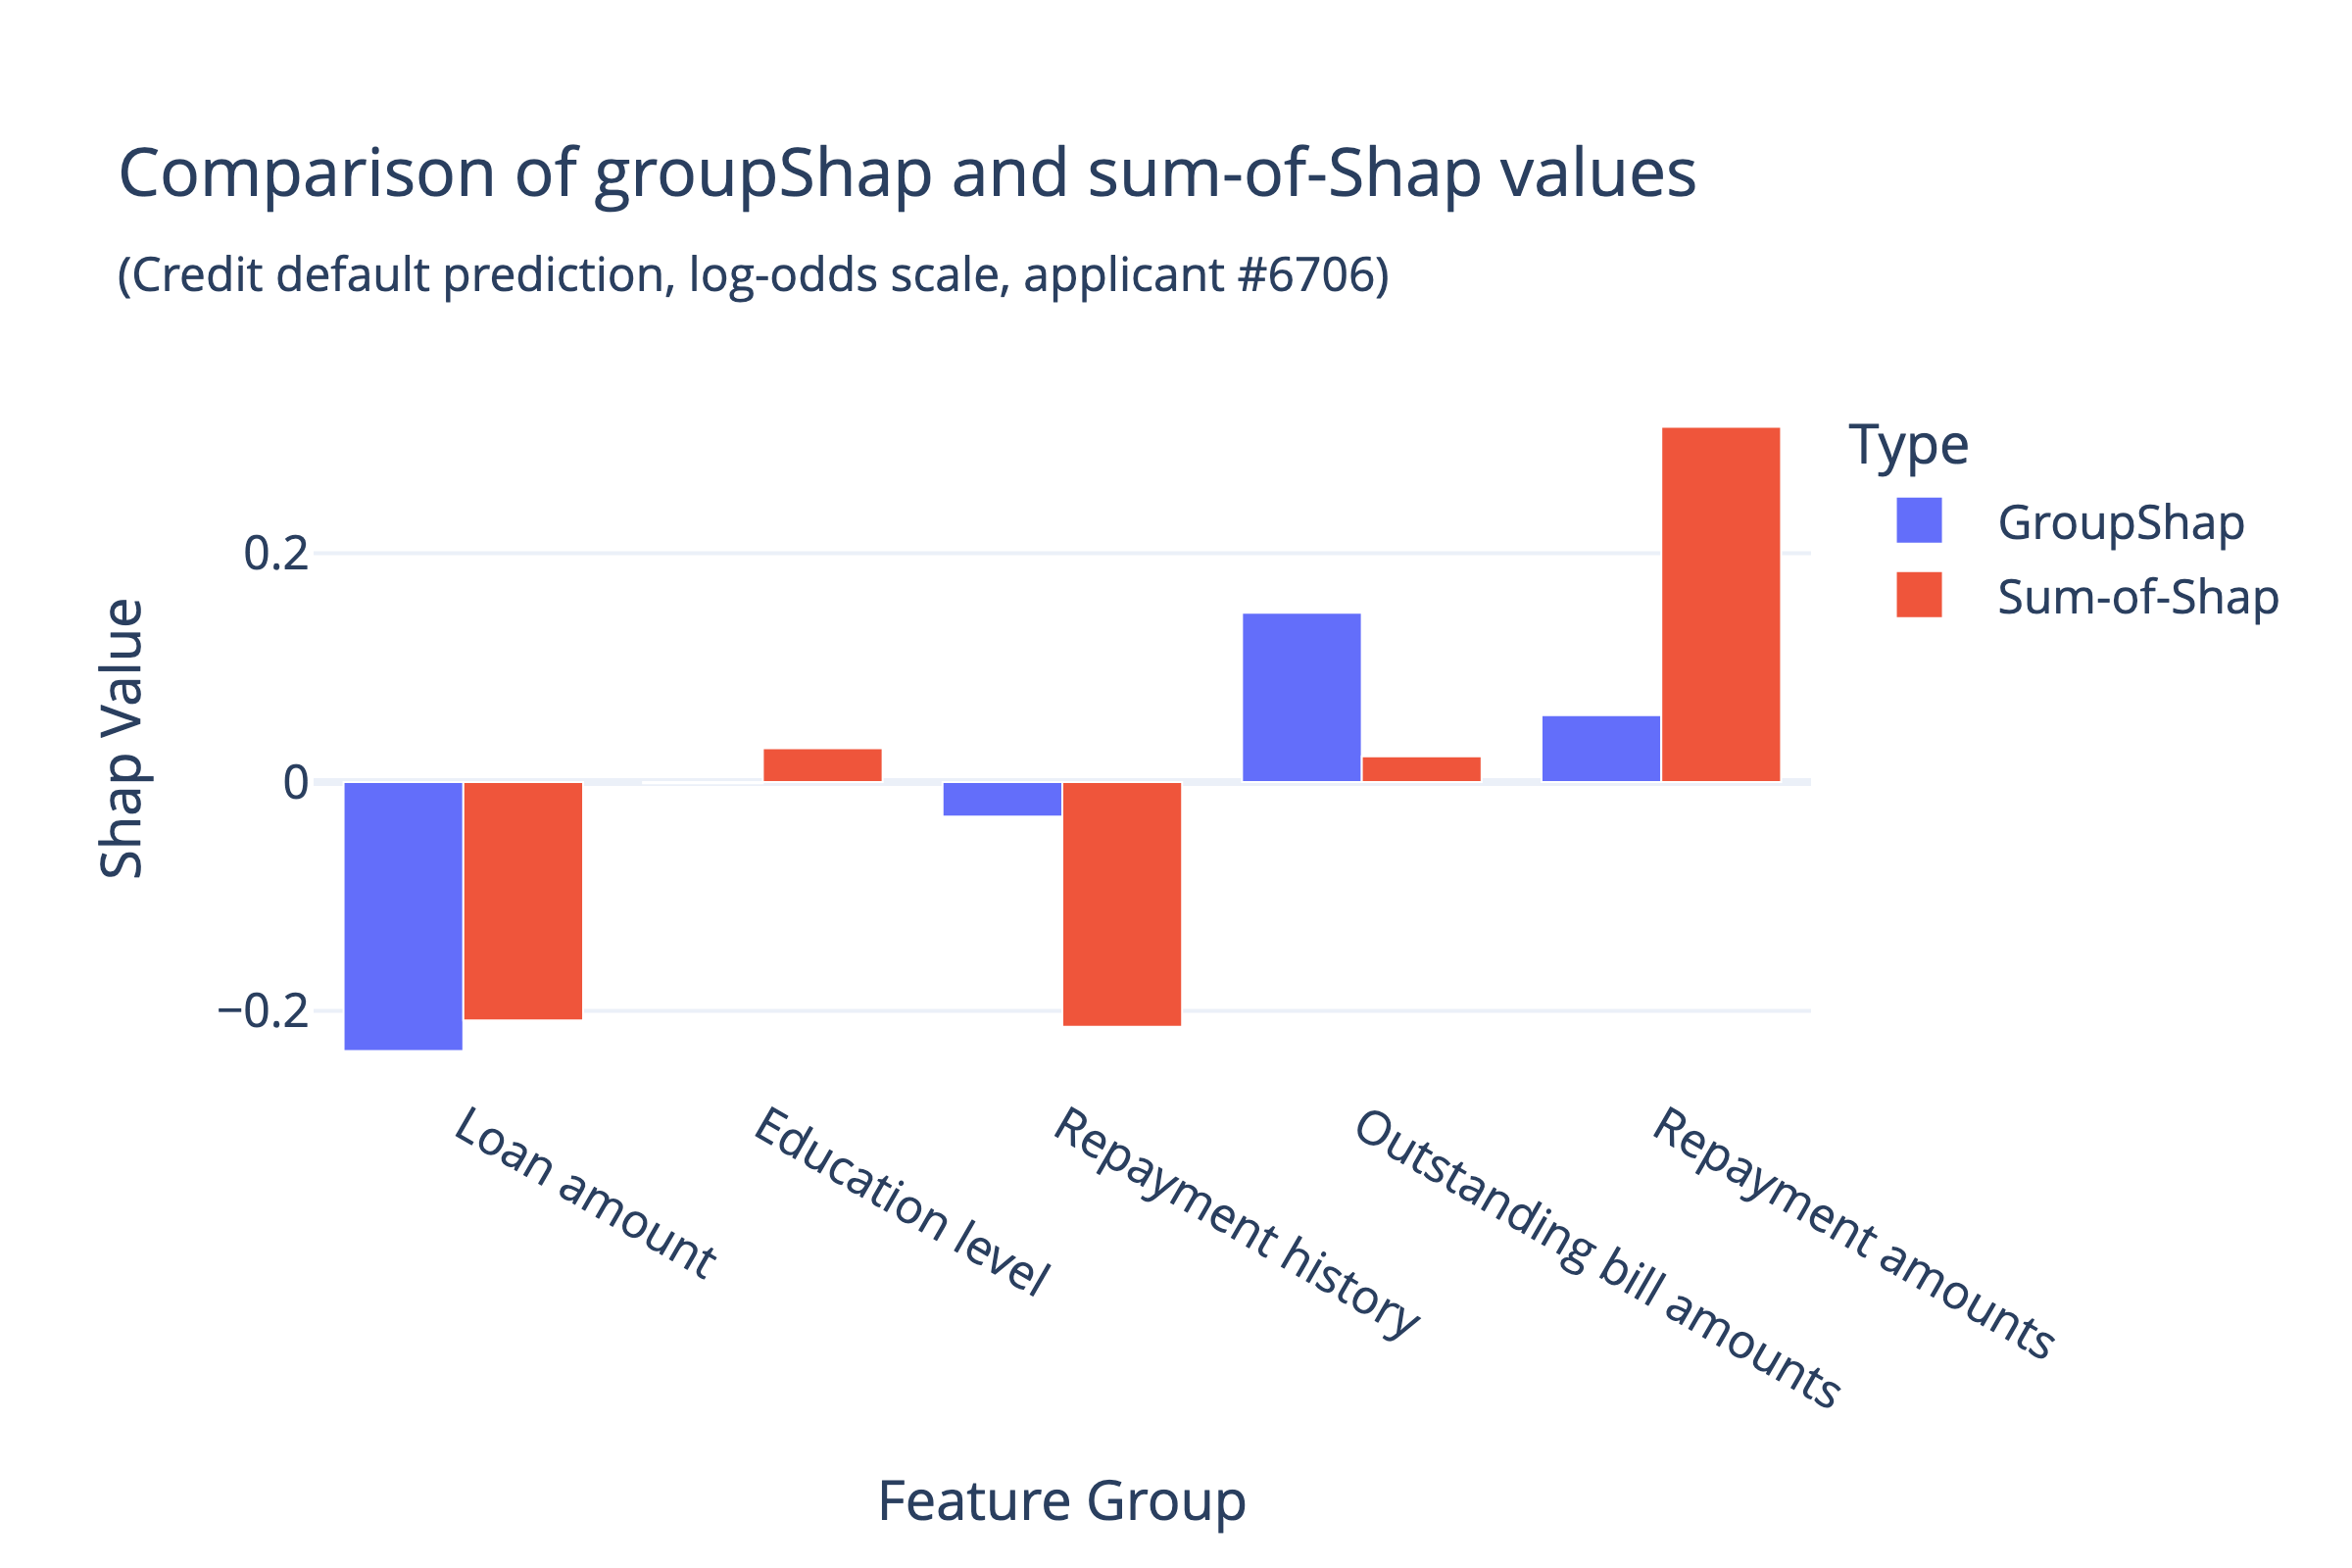

In [9]:
data = pd.concat(
    [
        pd.DataFrame(
            {
                "Feature Group": named_groupshap.keys(),
                "Shap Value": named_groupshap.values(),
                "Type": "GroupShap",
            }
        ),
        pd.DataFrame(
            {
                "Feature Group": named_sum_of_shap.keys(),
                "Shap Value": named_sum_of_shap.values(),
                "Type": "Sum-of-Shap",
            }
        ),
    ]
)

fig = px.bar(
    data,
    x="Feature Group",
    y="Shap Value",
    color="Type",
    barmode="group",
    title="Comparison of groupShap and sum-of-Shap values",
    subtitle=f"(Credit default prediction, log-odds scale, applicant #{j})",
    template="plotly_white",
)
fig.write_image("groupshap comparison.png", scale=4, width=600, height=400)
fig.show("png", scale=4, width=600, height=400)